# Denetimli Öğrenme - Destek Vektör Makineleri Kullanarak Sınıflandırma

## Destek Vektör Makinesi nedir?

Önceki bölümde, lojistik regresyon kullanarak sınıflandırma nasıl yapılacağını gördünüz. Bu bölümde ise, veri bilimciler arasında çok popüler olan başka bir denetimli makine öğrenimi algoritmasını öğreneceksiniz - Destek Vektör Makineleri (SVM). Lojistik regresyon gibi, SVM de bir sınıflandırma algoritmasıdır. SVM'nin arkasındaki temel fikir, iki veya daha fazla sınıf arasına en iyi şekilde bir çizgi çizmektir (bkz. Şekil 8.1).

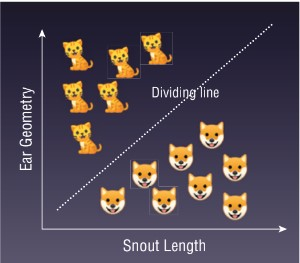

In [1]:
from IPython.display import Image

Image(filename='Figure-8.1.jpg')

**Şekil 8.1:** İki hayvan sınıfını ayırmak için SVM kullanımı

Sınıfları ayırmak için çizgi çizildikten sonra, bunu gelecekteki verileri tahmin etmek için kullanabilirsiniz. Örneğin, yeni bir bilinmeyen hayvanın burun uzunluğu ve kulak geometrisi verildiğinde, şimdi ayırma çizgisini bir sınıflandırıcı olarak kullanarak hayvanın bir köpek mi yoksa bir kedi mi olduğunu tahmin edebilirsiniz. Bu bölümde, SVM'nin nasıl çalıştığını ve doğrusal olarak ayrılamayan veri kümelerini çözmek için SVM'yi uyarlamak için kullanabileceğiniz çeşitli teknikleri öğreneceksiniz.

## Maksimum Ayrılabilirlik

SVM iki veya daha fazla sınıfı nasıl ayırır? Şekil 8.2'deki nokta kümesini düşünün. Sonraki şekle bakmadan önce, noktaları iki gruba ayıran düz bir çizgiyi göz önünde bulundurarak görsel olarak düşünün.

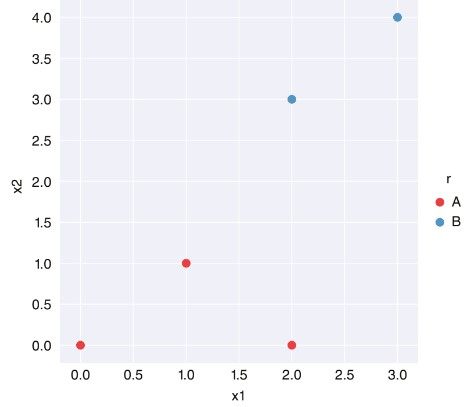

In [2]:
Image(filename='Figure-8.2.jpg')

**Şekil 8.2:** SVM kullanılarak ayrılabilen bir nokta kümesi

Şimdi Şekil 8.3'e bakın, bu noktaların iki grup arasında ayıran iki olası çizgiyi gösteriyor. Bu sizin aklınızda olan şey miydi? Her iki çizgi de noktaları iki farklı gruba ayırır, ancak hangisi doğru olanıdır? SVM için doğru çizgi, her bir sınıfta en az bir noktaya dokunan geniş bir marjinal alana sahip olan çizgidir, Şekil 8.4'te gösterildiği gibi. O şekilde, d1 ve d2 marjin genişlikleridir. Amaç, iki grubu ayırabilen en geniş marjin genişliğini bulmaktır. Dolayısıyla, bu durumda d2 en büyüktür. Bu nedenle, seçilen çizgi sağdaki çizgidir.

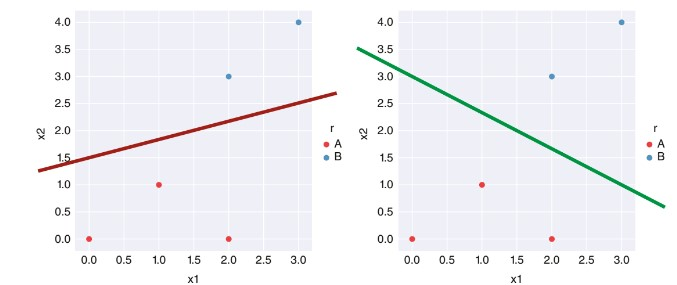

In [3]:
Image(filename='Figure-8.3.jpg')

**Şekil 8.3:** Noktaları iki sınıfa bölmek için iki olası yol

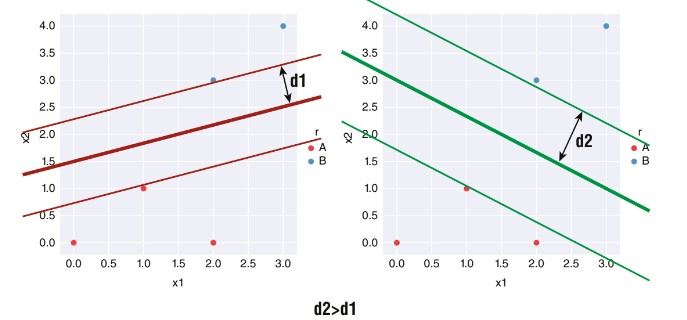

In [4]:
Image(filename='Figure-8.4.jpg')

**Şekil 8.4:** SVM, iki sınıfı en geniş marjin ile ayırmayı amaçlar

İki marjinden her biri, her nokta grubuna en yakın noktaları dokunur ve iki marjinin merkezi hiper düzlem olarak bilinir. Hiper düzlem, noktaların iki grubunu ayıran çizgidir. "Hiper düzlem" terimini "çizgi" yerine kullanıyoruz çünkü SVM'de genellikle iki boyuttan fazla boyutla uğraşırız ve "hiper düzlem" kelimesinin daha doğru bir şekilde çok boyutlu bir uzayda bir düzlem fikrini ilettiğini söyleyebiliriz.

## Destek Vektörler
SVM'deki önemli bir terim destek vektörlerdir. Destek vektörleri, iki marjin üzerinde yer alan noktalardır. Önceki bölümdeki örneği kullanarak, Şekil 8.5, iki destek vektörünü iki marjin üzerinde göstermektedir. Bu durumda, her bir sınıf için birer destek vektörü olduğunu söyleriz.

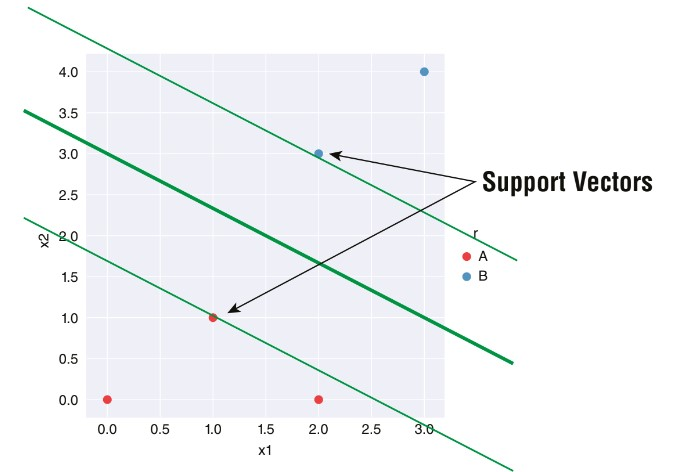

In [5]:
Image(filename='Figure-8.5.jpg')

**Şekil 8.5:** Destek vektörleri, marjinler üzerinde yer alan noktalardır

## Hiperdüzlem için Formül

Noktalar serisiyle birlikte, bir sonraki soru hiperdüzlem için formülü bulmak olacaktır, bununla birlikte iki marjin de yer alır. Bu konunun matematiğine çok fazla girmeden, Şekil 8.6, hiperdüzlemi elde etmek için formülü göstermektedir.

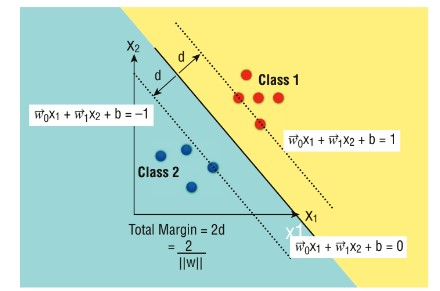

In [6]:
Image(filename='Figure-8.6.jpg')

**Şekil 8.6:** Hiperdüzlem için formül ve ona eşlik eden iki marjin

Şekil 8.6'dan görebileceğiniz gibi, hiperdüzlem için formül (g) şu şekildedir:

$$ g = \rho_{W0} \cdot x_1 + \rho_{W1} \cdot x_2 + b $$

Burada, $(x_1)$ ve $(x_2)$ girdileri, $\rho_{W0}$ ve $\rho_{W1}$ ağırlık vektörleri ve $b$ sapmadır.

Eğer g değeri 1 ise, belirtilen nokta 1. Sınıfta yer alır, ve eğer g değeri -1 ise, belirtilen nokta 2. Sınıfta yer alır. SVM'nin amacı, sınıfları bölen en geniş marjinleri bulmaktır ve toplam marjin (2d) aşağıdaki gibi tanımlanır:

$$ 2/dw $$

Burada, $w$ normalleştirilmiş ağırlık vektörleridir $\rho_{W0}$ ve $\rho_{W1}$. Eğitim seti kullanılarak, sınıflar arasındaki maksimum ayrılabilirliği elde etmek için $w$ değerini minimize etmek hedeflenir. Bu yapıldığında, $\rho_{W0}$, $\rho_{W1}$ ve $b$ değerlerini elde edebilirsiniz.

Marjini bulmak, Kısıtlanmış Optimizasyon problemini çözmek demektir, bu da Larange Çarpanları tekniği kullanılarak çözülebilir. Veri kümesine dayanarak marjini nasıl bulacağımızı tartışmanın bu kitabın kapsamı dışındadır, ancak bunları bulmak için Scikit-learn kütüphanesinden yararlanacağımızı belirtmek yeterlidir.


## SVM için Scikit-learn Kullanımı

Şimdi SVM'nin nasıl çalıştığını ve Scikit-learn kullanarak nasıl uygulanacağını görmek için bir örnek üzerinde çalışalım. Bu örnekte, aşağıdaki verileri içeren svm.csv adlı bir dosyaya sahibiz:

İlk yapacağımız şey, Noktaları Seaborn kullanarak çizmek olacak:

C:\Users\Furkan\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


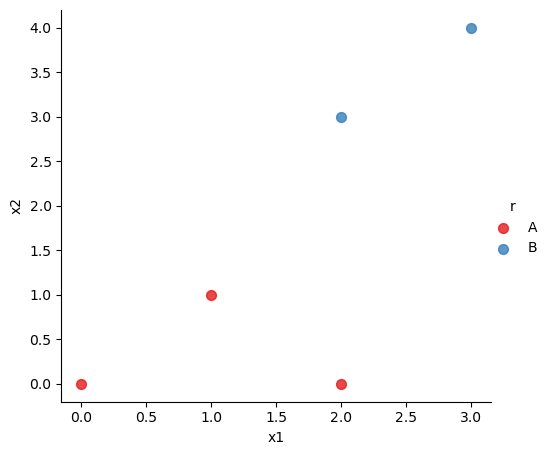

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO

# svm.csv dosyası yerine csv formatında kod dizininde veri tabanı oluşturdum.
csv_data = """
x1,x2,r
0,0,A
1,1,A
2,3,B
2,0,A
3,4,B
"""

# Veriyi oku
data = pd.read_csv(StringIO(csv_data))

# lmplot ile görselleştirme
sns.lmplot(x='x1', y='x2',
           data=data,
           hue='r',
           palette='Set1',
           fit_reg=False,
           scatter_kws={"s": 50})

plt.subplots_adjust(top=0.9, right=0.9)
plt.show()

Şekil 8.7, Seaborn kullanılarak çizilen noktaları göstermektedir.

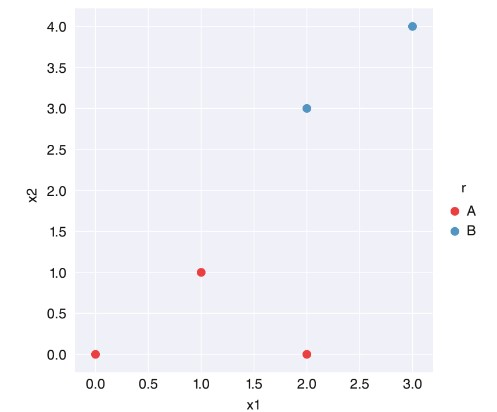

In [8]:
Image(filename='Figure-8.7.jpg')

Önceden yüklediğimiz veri noktalarını kullanarak, şimdi Scikit-learn kütüphanesinin svm modülündeki SVC sınıfını kullanarak, aksi takdirde hesaplamamız gereken çeşitli değişkenlerin değerini elde etmemize yardımcı olalım. Aşağıdaki kod parçası, sorunu çözmek için doğrusal çekirdeği kullanır. Doğrusal çekirdek, veri setinin doğrusal olarak ayrılabilir olduğunu varsayar.

In [38]:
from sklearn import svm
import numpy as np
#---Converting the Columns as Matrices---
points = data[['x1','x2']].values
result = data['r']
clf = svm.SVC(kernel = 'linear')
clf.fit(points, result)
print('Vector of weights (w) = ',clf.coef_[0])
print('b = ',clf.intercept_[0])
print('Indices of support vectors = ', clf.support_)
print('Support vectors = ', clf.support_vectors_)
print('Number of support vectors for each class = ', clf.n_support_)
print('Coefficients of the support vector in the decision function = ',
np.abs(clf.dual_coef_))

Vector of weights (w) =  [0.4 0.8]
b =  -2.2
Indices of support vectors =  [1 2]
Support vectors =  [[1. 1.]
 [2. 3.]]
Number of support vectors for each class =  [1 1]
Coefficients of the support vector in the decision function =  [[0.4 0.4]]


SVC, Destek Vektör Sınıflandırması'nın kısaltmasıdır. svm modülü, farklı amaçlar için SVM'yi uygulayan bir dizi sınıf içerir:

- svm.LinearSVC: Doğrusal Destek Vektör Sınıflandırması
- svm.LinearSVR: Doğrusal Destek Vektörü Regresyonu
- svm.NuSVC: Nu-Destek Vektör Sınıflandırması
- svm.NuSVR: Nu-Destek Vektörü Regresyonu
- svm.OneClassSVM: Denetimsiz Aykırı Değer Tespiti
- svm.SVC: C-Destek Vektör Sınıflandırması
- svm.SVR: Epsilon-Destek Vektör Regresyonu

**İpucu:** Bu bölümde, odak noktamız SVM'in sınıflandırma için kullanılmasıdır, SVM aynı zamanda regresyon için de kullanılabilir.

Önceki kod parçası şu çıktıyı verir:

Görüldüğü gibi, ağırlık vektörü $\begin{bmatrix} 0.4 \ 0.8 \end{bmatrix}$ olarak bulunmuştur, bu da $W_0$'ın şimdi 0.4 ve $W_1$'in şimdi 0.8 olduğu anlamına gelir. $b$'nin değeri $-2.2$'dir ve iki destek vektör bulunmaktadır. Destek vektörlerinin dizini 1 ve 2'dir, yani kalın harflerle belirtilen noktalardır:

Şekil 8.8, formüldeki çeşitli değişkenler ile kod parçacığındaki değişkenler arasındaki ilişkiyi göstermektedir.

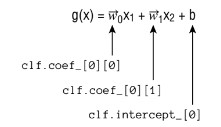

In [10]:
Image(filename='Figure-8.8.jpg')

**Şekil 8.8:** Formüldeki değişkenler ile kod parçacığındaki değişkenler arasındaki ilişkiler

## Hiperyüzeyi ve Marjinleri Çizmek

Değişkenlerin tüm değerleri elde edildiğine göre, şimdi hiperyüzeyi ve onun iki eşlik eden marjini çizme zamanı geldi. Hiperyüzeyin formülünü hatırlıyor musunuz? Şöyle:

$ g(\mathbf{X}) = \mathbf{W}^T \mathbf{X} + b $

Hiperyüzeyi çizmek için, $\mathbf{W}_0 = 1$, $\mathbf{W}_1 = 2$ ve $b = 0$ olarak ayarlayın, şöyle:

$ \mathbf{W}_0 = 1, \quad \mathbf{W}_1 = 2, \quad b = 0 $

Hiperyüzeyi çizmek için (bu durumda düz bir çizgi), iki noktaya ihtiyacımız var: biri x-ekseninde, diğeri y-ekseninde. Yukarıdaki formülü kullanarak, $x_1 = 0$ olduğunda, $x_2$ için şöyle çözebiliriz:

$ \mathbf{W}_0(0) + \mathbf{W}_1x_2 + b = 0 \quad \Rightarrow \quad \mathbf{W}_1x_2 = -b $

$ x_2 = -\frac{b}{\mathbf{W}_1} $

$x_2 = 0$ olduğunda, $x_1$ için şöyle çözebiliriz:

$ \mathbf{W}_0x_1 + \mathbf{W}_1(0) + b = 0 \quad \Rightarrow \quad \mathbf{W}_0x_1 = -b $

$ x_1 = -\frac{b}{\mathbf{W}_0} $

Nokta $0,-\frac{b}{\mathbf{W}_1}$, düz çizginin y-kesişimidir. Şekil 8.9, iki eksen üzerindeki iki noktayı gösterir.

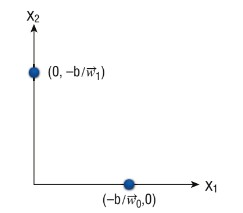

In [11]:
Image(filename='Figure-8.9.jpg')

**Şekil 8.9:** Hiperyüzey için iki kesim noktası

Eksenlerdeki noktalar bulunduktan sonra, eğimi şu şekilde hesaplayabilirsiniz:

Eğim = $\frac{-b}{\frac{b}{\mathbf{W}_1}} \div \frac{b}{\mathbf{W}_0}$

Eğim = $-\frac{\mathbf{W}_0}{\mathbf{W}_1}$

Eğimin ve doğrunun y-kesişiminin bulunmasının ardından, hiperyüzeyi çizmek için ilerleyebilirsiniz. Aşağıdaki kod parçacığı bunu yapıyor:

In [12]:
#---w ağırlık vektörüdür---
w = clf.coef_[0]
#---hiperyüzeyin eğimini bul---
eğim = -w[0] / w[1]
b = clf.intercept_[0]
#---hiperyüzey için koordinatları bul---
xx = np.linspace(0, 4)
yy = eğim * xx - (b / w[1])
#---kenar boşluklarını çiz---
s = clf.support_vectors_[0] #---ilk destek vektörü---
yy_down = eğim * xx + (s[1] - eğim * s[0])
s = clf.support_vectors_[-1] #---son destek vektörü---
yy_up = eğim * xx + (s[1] - eğim * s[0])
#---noktaları çiz---
sns.lmplot(x='x1', y='x2', data=data, hue='r', palette='Set1', fit_reg=False, scatter_kws={"s": 70})
#---hiperyüzeyi çiz---
plt.plot(xx, yy, linewidth=2, color='green');
#---2 kenar boşluğunu çiz---
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')

NameError: name 'np' is not defined

Şekil 8.10, hiperyüzeyi ve iki kenar boşluğunu göstermektedir.

## Tahminler Yapma

Unutmayın, SVM'nin amacı noktaları iki veya daha fazla sınıfa ayırmaktır, böylece gelecekteki noktaların sınıflarını tahmin etmek için kullanabilirsiniz. SVM'yi kullanarak modelinizi eğittikten sonra, şimdi modeli kullanarak bazı tahminler yapabilirsiniz. Aşağıdaki kod parçacığı, eğittiğiniz modeli kullanarak bazı tahminler yapar:

In [ ]:
print(clf.predict([[3,3]])[0])
print(clf.predict([[4,0]])[0])
print(clf.predict([[2,2]])[0])
print(clf.predict([[1,2]])[0])

B
A
B
A


Şekil 8.10'da gösterilen grafikle noktaları kontrol edin ve bu size mantıklı geliyor mu diye bakın.

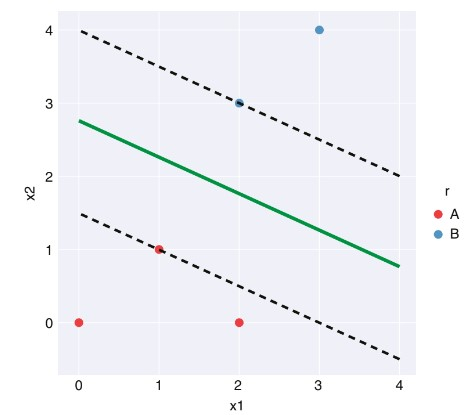

In [14]:
Image(filename='Figure-8.10.jpg')

**Şekil 8.10:** Hiperyüzey ve iki kenar boşluğu

## Çekirdek Hilesi

Bazen, bir veri kümesindeki noktalar her zaman doğrusal olarak ayrılabilir değildir. Şekil 8.11'de gösterilen noktaları düşünün.

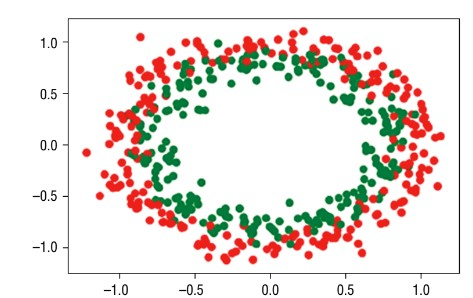

In [15]:
Image(filename='Figure-8.11.jpg')

**Şekil 8.11:** Dairesel şekilde dağılmış iki grup noktanın saçılım grafiği

İki nokta kümesini ayırmak için düz bir çizgi çizmek mümkün olmadığını görebilirsiniz. Ancak, bazı manipülasyonlarla bu nokta kümesini doğrusal olarak ayrılabilir hale getirebilirsiniz. Bu teknik, çekirdek hilesi olarak bilinir. Çekirdek hilesi, veriyi bir makine öğrenimi tekniği olan yüksek boyutlu bir uzaya dönüştüren ve dönüştürmeden sonra verilerin sınıfları arasında net bir ayrım kenarı bulunan bir tekniktir.

## Üçüncü Bir Boyut Ekleme

Bunu yapmak için üçüncü bir boyut ekleyebiliriz, mesela z-eksenini, ve z' yi şöyle tanımlayabiliriz: $z = x^2 + y^2$.

Noktaları 3B grafik kullanarak çizdiğimizde, noktalar artık doğrusal olarak ayrılabilir hale gelir. Bunun görselleştirilmesi zordur, ancak noktaları çizmedikçe anlamak zor olabilir. Aşağıdaki kod örneği bunu gerçekleştirir:


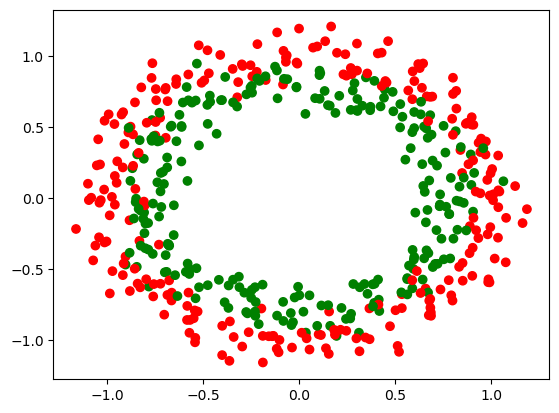

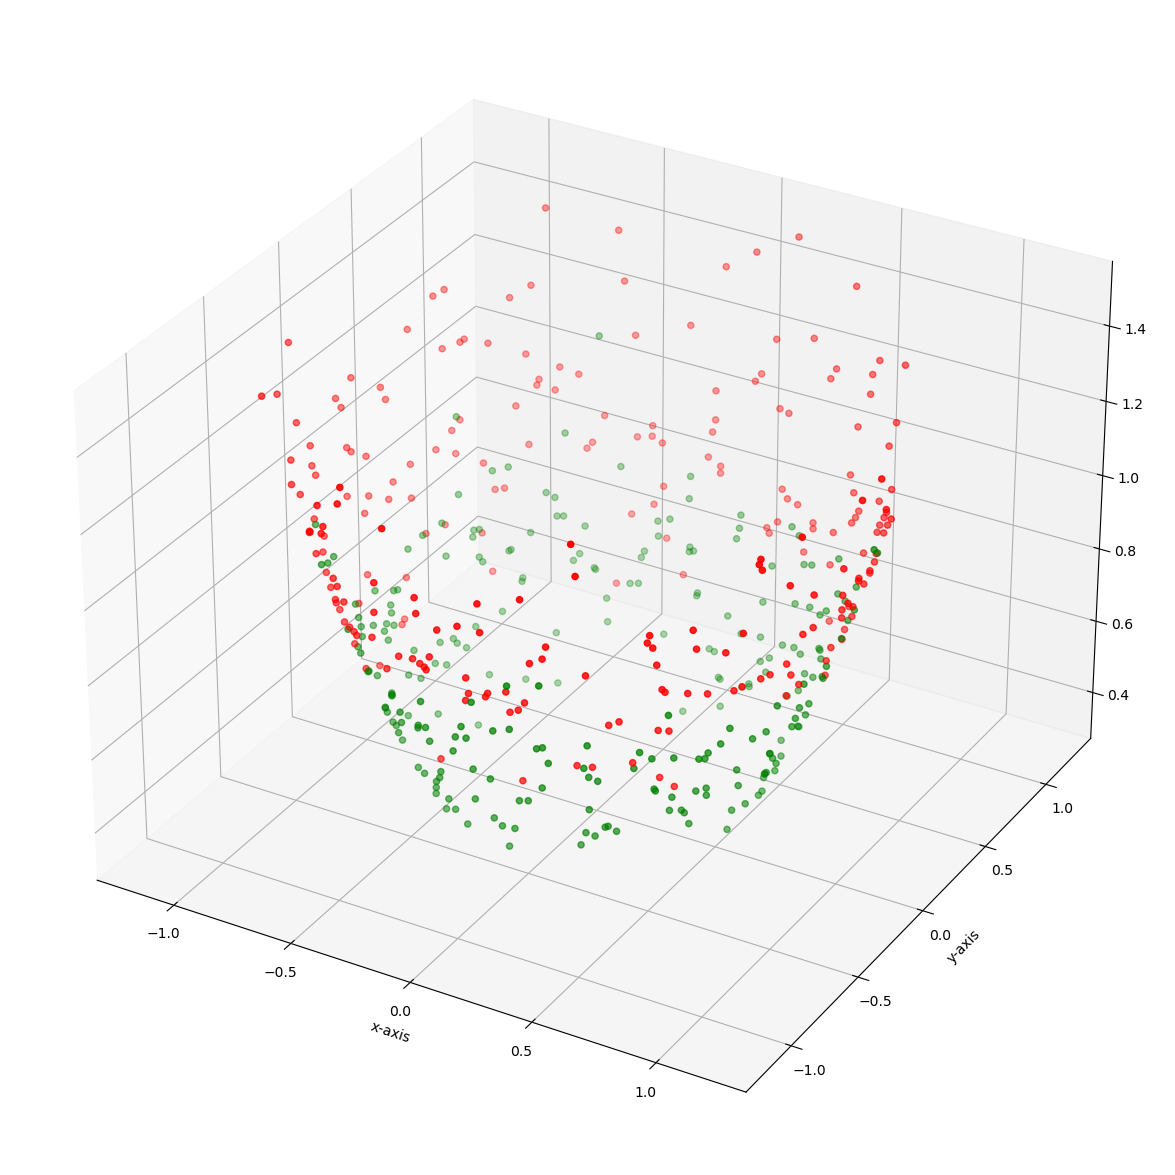

In [16]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
#---X is features and c is the class labels---
X, c = make_circles(n_samples=500, noise=0.09)
rgb = np.array(['r', 'g'])
plt.scatter(X[:, 0], X[:, 1], color=rgb[c])
plt.show()
fig = plt.figure(figsize=(18,15))
ax = fig.add_subplot(111, projection='3d')
z = X[:,0]**2 + X[:,1]**2
ax.scatter(X[:, 0], X[:, 1], z, color=rgb[c])
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()

Öncelikle, make_circles() fonksiyonunu kullanarak dairesel bir şekilde dağılmış toplam 500 noktadan oluşan iki küme rastgele nokta oluşturuyoruz. Ardından, bu noktaları 2B bir grafik üzerinde çiziyoruz (Şekil 8.11'de gösterildiği gibi). Daha sonra, üçüncü eksen olan z-eksenini ekliyoruz ve grafiği 3B olarak çiziyoruz (Şekil 8.12'ye bakınız).

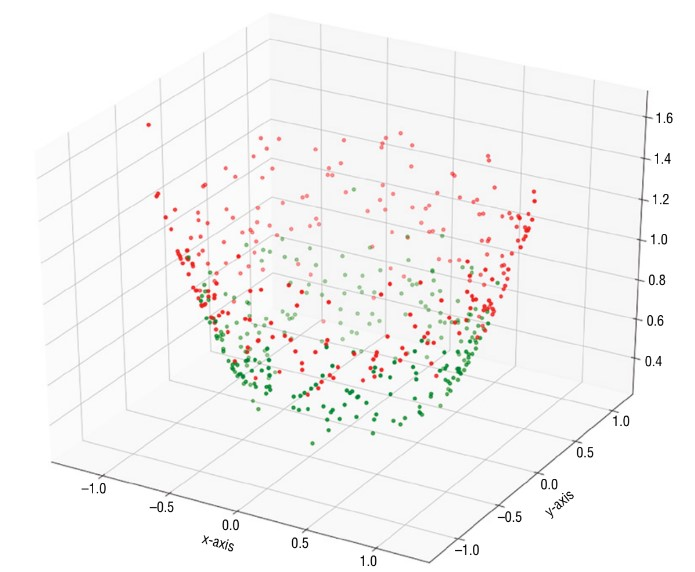

In [17]:
Image(filename='Figure-8.12.jpg')

**Şekil 8.12:** Noktaların üç boyutta çizimi

**İpucu:** **Yukarıdaki kodu Terminal'de çalıştırırsanız (kod parçacığının başındaki** %matplotlib inline **ifadesini kaldırarak sadece** python **komutunu kullanın), grafiği döndürüp etkileşimde bulunabilirsiniz. Şekil 8.13, 3B grafiğin farklı bakış açılarını göstermektedir.**

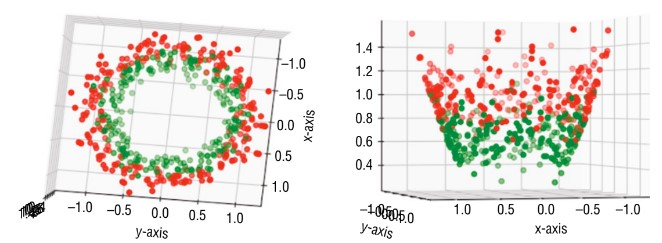

In [18]:
Image(filename='Figure-8.13.jpg')

**Şekil 8.13:** Aynı veri setinin 3B'deki farklı bakış açıları

## 3B Hiperyüzeyi Çizme

Noktaları 3B grafikte çizdikten sonra, şimdi modeli üçüncü boyutu kullanarak eğitelim:

In [19]:
#---X (x-ekseni, y-ekseni) ve z'yi tek bir ndarray içinde birleştir---
features = np.concatenate((X,z.reshape(-1,1)), axis=1)

#---SVM kullanarak eğitim yap---
from sklearn import svm
clf = svm.SVC(kernel = 'linear')
clf.fit(features, c)

SVC(kernel='linear')

İlk olarak, üç eksenleri \texttt{np.concatenate()} fonksiyonunu kullanarak tek bir ndarray içinde birleştirdik. Ardından modeli normal şekilde eğittik. İki boyutta doğrusal olarak ayrılabilen bir nokta kümesi için, hiperyüzeyin formülü şu şekildedir:
$$\[ g(x) = \mathbf{W}_0X_1 + \mathbf{W}_1X_2 + b \]$$

Şimdi üç boyutta bulunan nokta kümesi için, formül şu şekilde olur:
$$\[ g(x) = \mathbf{W}_0X_1 + \mathbf{W}_1X_2 + \mathbf{W}_2X_3 + b \]$$

Özellikle, $W_2$ artık $\texttt{clf.coef\_[0][2]}$ tarafından temsil edilir, Şekil 8.14'te gösterildiği gibi.

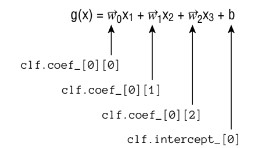

In [20]:
Image(filename='Figure-8.14.jpg')

**Şekil 8.14:** 3B'de hiperyüzeyin formülü ve kod parçacığındaki karşılık gelen değişkenler

Sonraki adım, hiperyüzeyi 3B'de çizmektir. Bunun için, Şekil 8.15'te gösterildiği gibi türetilebilecek x3 değerini bulmanız gerekir.

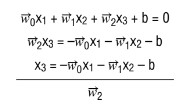

In [21]:
Image(filename='Figure-8.15.jpg')

**Şekil 8.15:** 3D'de hiperyüzeyi bulma formülü

Bu kodda şu şekilde ifade edilebilir:

3B'de hiperyüzeyi çizmek için plot_surface() fonksiyonunu kullanın:

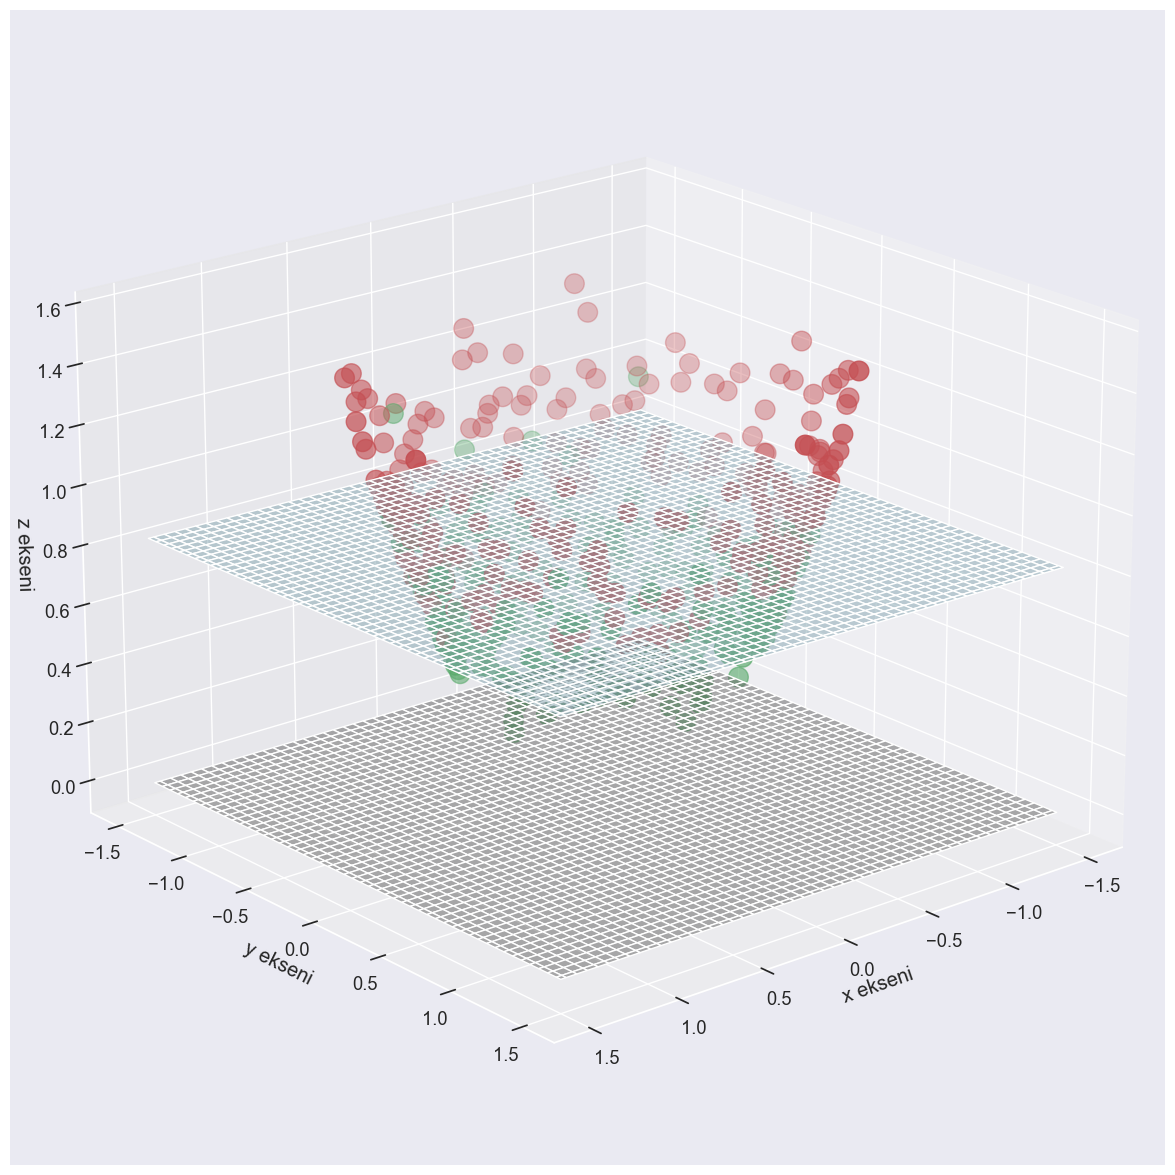

In [84]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles

#---X is features and c is the class labels---
X, c = make_circles(n_samples=500, noise=0.09)
z = X[:,0]**2 + X[:,1]**2
rgb = np.array(['r', 'g'])

fig = plt.figure(figsize=(18,15))
ax = fig.add_subplot(111, projection='3d')

# Veri noktalarını 3 boyutlu alanda göster
ax.scatter(X[:, 0], X[:, 1], z, color=rgb[c], s=200)

# Eksen etiketlerini belirt
ax.set_xlabel("x ekseni")
ax.set_ylabel("y ekseni")
ax.set_zlabel("z ekseni")

# x ve y düzlemlerini belirleme
tmp = np.linspace(-1.5, 1.5, 100)
x, y = np.meshgrid(tmp, tmp)
ax.plot_surface(x, y, np.zeros_like(x), alpha=0.5, color='gray')

#---combine X (x-axis,y-axis) and z into single ndarray---
features = np.concatenate((X,z.reshape(-1,1)), axis=1)

#---use SVM for training---
from sklearn import svm
clf = svm.SVC(kernel = 'linear')
clf.fit(features, c)

# Hiperdüzlemi çizme
x3 = lambda x,y: (-clf.intercept_[0] - clf.coef_[0][0] * x - clf.coef_[0][1] * y) / clf.coef_[0][2]
ax.plot_surface(x, y, x3(x, y), alpha=0.5, color='lightblue')

ax.view_init(azim=50, elev=20)

plt.show()

Şekil 8.16, hiperyüzeyi ve noktaları 3B'de göstermektedir.

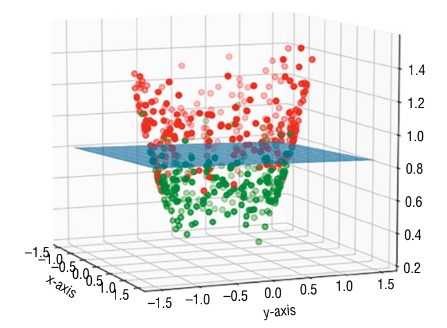

In [23]:
Image(filename='Figure-8.16.jpg')

**Şekil 8.16:** İki nokta kümesini kesen hiperyüzeyin 3D'deki görünümü

## Çekirdek Türleri 

Şu ana kadar, yalnızca bir tür SVM - doğrusal SVM - üzerinde konuştuk. Adından da anlaşılacağı gibi, doğrusal SVM noktaları ayırmak için düz bir çizgi kullanır. Önceki bölümde, iki veri kümesini dairesel bir şekilde ayırmak için çekirdek hilelerinin kullanımını öğrendiniz ve ardından bunları ayırmak için doğrusal SVM kullandınız. Bazen tüm noktalar doğrusal olarak ayrılamaz veya önceki bölümde gözlemlediğiniz çekirdek hileleri kullanılarak ayrılamaz. Bu tür veriler için, onları ayırmak için "çizgileri eğmek" gerekir. Makine öğreniminde, çekirdekler verinizi doğrusal olmayan uzaylardan doğrusal uzaylara dönüştüren fonksiyonlardır. Çekirdeklerin nasıl çalıştığını anlamak için, Iris veri kümesini bir örnek olarak kullanalım. Aşağıdaki kod parçacığı Iris veri kümesini yükler ve özellikleri, hedefi ve hedef isimlerini yazdırır:

In [24]:
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn import svm, datasets
import matplotlib.pyplot as plt

iris = datasets.load_iris()
print(iris.data[0:5]) # print first 5 rows
print(iris.feature_names) # ['sepal length (cm)', 'sepal width (cm)',
# 'petal length (cm)', 'petal width (cm)']
print(iris.target[0:5]) # print first 5 rows
print(iris.target_names) # ['setosa' 'versicolor' 'virginica']

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0 0 0 0 0]
['setosa' 'versicolor' 'virginica']


Göstermek için, sadece Iris veri kümesinin ilk iki özelliğini kullanacağız:

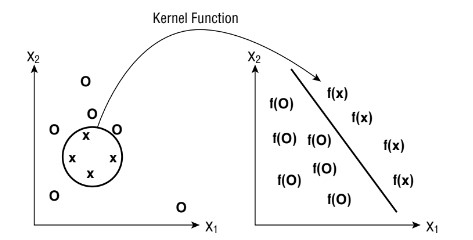

In [25]:
Image(filename='Figure-8.17.jpg')

**Şekil 8.17:** Bir çekirdek fonksiyonu, verinizi doğrusal olmayan uzaylardan doğrusal olanlara dönüştürür

In [26]:
X = iris.data[:, :2] # take the first two features
y = iris.target

Noktaları bir saçılma grafiği kullanarak çizeceğiz (Şekil 8.18'e bakınız):

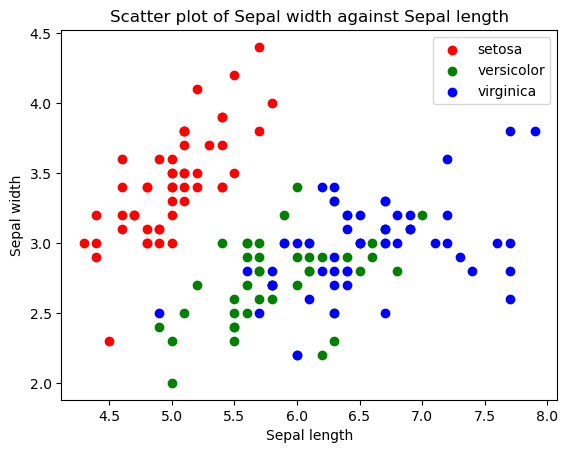

In [27]:
#---noktaları çiz---
colors = ['red', 'green', 'blue']
for color, i, target in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X[y==i, 0], X[y==i, 1], color=color, label=target)

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('Scatter plot of Sepal width against Sepal length')
plt.show()

Sonraki adımda, doğrusal çekirdek ile SVC sınıfını kullanacağız:

In [28]:
C = 1 # SVM regularization parameter
clf = svm.SVC(kernel='linear', C=C).fit(X, y)
title = 'SVC with linear kernel'

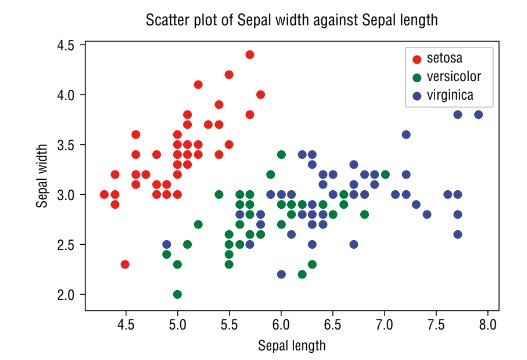

In [29]:
Image(filename='Figure-8.18.jpg')

**Şekil 8.18:** Iris veri kümesinin ilk iki özelliğinin saçılma grafiği

**İpucu:** Bu sefer C adında yeni bir parametremiz olduğunu fark ettiniz mi? Bunun hakkında biraz sonra konuşacağız.

Bu sefer üç Iris çiçeği grubunu ayırmak için çizgiler yerine, grupları renklerle boyayacağız ve bunun için contourf() fonksiyonunu kullanacağız:

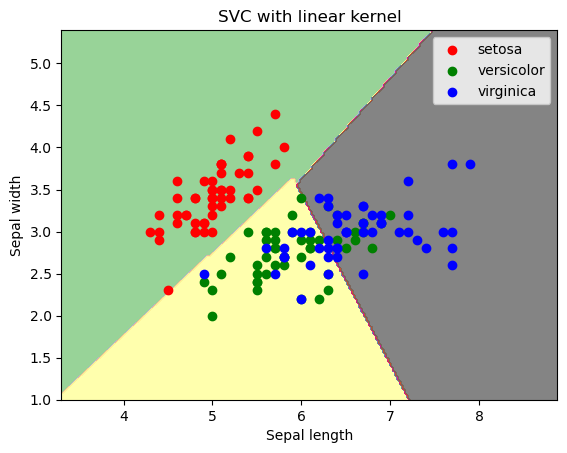

In [30]:
#---min and max for the first feature---
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
#---min and max for the second feature---
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
#---step size in the mesh---
h = (x_max / x_min)/100
#---make predictions for each of the points in xx,yy---
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
#---draw the result using a color plot---
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Accent, alpha=0.8)
#---plot the training points---
colors = ['red', 'green', 'blue']
for color, i, target in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X[y==i, 0], X[y==i, 1], color=color, label=target)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title(title)
plt.legend(loc='best', shadow=False, scatterpoints=1)

Şekil 8.19, saçılma graflarını ve SVM doğrusal çekirdeği tarafından belirlenen grupları göstermektedir.

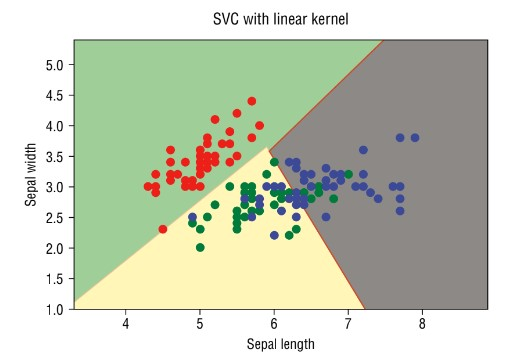

In [31]:
Image(filename='Figure-8.19.jpg')

**Şekil 8.19:** SVM doğrusal çekirdeği kullanarak

Eğitim tamamlandıktan sonra bazı tahminler yapacağız:

In [32]:
predictions = clf.predict(X)
print(np.unique(predictions, return_counts=True))

(array([0, 1, 2]), array([50, 53, 47], dtype=int64))


Önceki kod parçası aşağıdakileri döndürür:

Bu, Iris veri kümesiyle modeli besledikten sonra 50'sinin "setosa" olarak sınıflandırıldığını, 53'ünün "versicolor" olarak sınıflandırıldığını ve 47'sinin "virginica" olarak sınıflandırıldığını gösterir.

## C

Önceki bölümde, C parametresinin kullanımını gördünüz:

In [33]:
C = 1
clf = svm.SVC(kernel='linear', C=C).fit(X, y)

C, hata terimi ceza parametresi olarak bilinir. Düzgün karar sınırı ve eğitim noktalarını doğru bir şekilde sınıflandırma arasındaki dengeyi kontrol eder. Örneğin, C değeri yüksekse, SVM algoritması tüm noktaların doğru bir şekilde sınıflandırılmasını sağlamaya çalışacaktır. Bunun dezavantajı, bunun daha dar bir marjla sonuçlanabileceğidir, Şekil 8.20'de gösterildiği gibi.

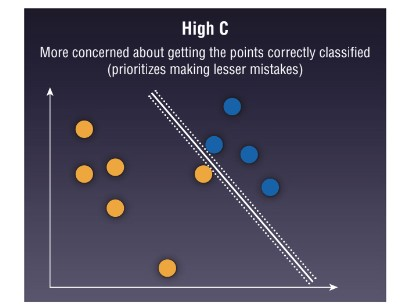

In [34]:
Image(filename='Figure-8.20.jpg')

**Şekil 8.20:** Yüksek C, noktaların doğru bir şekilde sınıflandırılmasına daha fazla odaklanır

Buna karşılık, daha düşük bir C, mümkün olan en geniş marjı hedefleyecektir, ancak bazı noktaların yanlış sınıflandırılmasına neden olacaktır (bkz. Şekil 8.21).

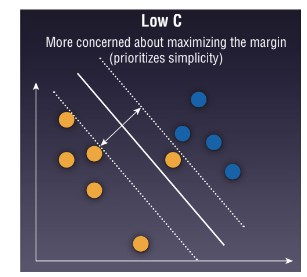

In [35]:
Image(filename='Figure-8.21.jpg')

**Şekil 8.21:** Düşük C, en geniş marjı hedefler, ancak bazı noktaları yanlış sınıflandırabilir.

Şekil 8.22, SVM doğrusal çekirdek algoritması uygulanırken C değerini değiştirmenin etkilerini gösterir. Sınıflandırmanın sonucu her bir grafik altında görünmektedir.

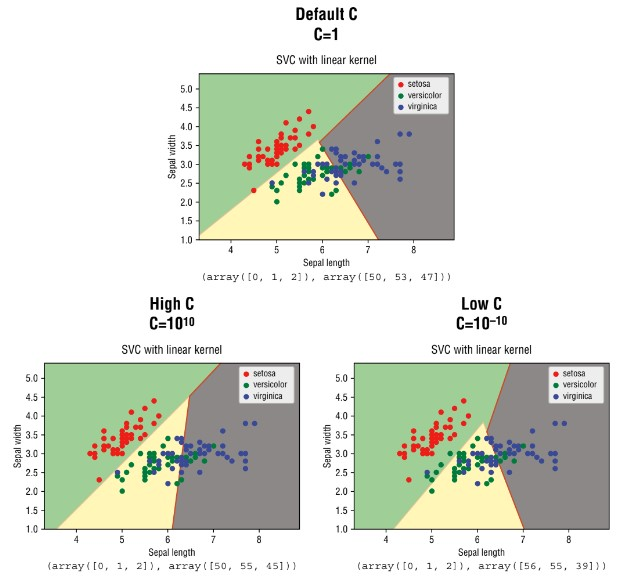

In [36]:
Image(filename='Figure-8.22.jpg')

**Şekil 8.22:** Farklı C değerleriyle SVM kullanımı

C'nin 1 veya 10^10 olduğunda, sınıflandırma sonuçları arasında çok fazla fark yoktur. Ancak C küçük olduğunda (10^−10), "versicolor" ve "virginica"ya ait birkaç noktanın artık "setosa" olarak yanlış sınıflandırıldığını görebilirsiniz.

**İpucu:** Kısacası, düşük bir C, karar yüzeyini düzleştirirken çoğu noktayı sınıflandırmaya çalışırken, yüksek bir C, tüm noktaları doğru bir şekilde sınıflandırmaya çalışır.

## Radial Basis Fonksiyon (RBF) Çekirdeği 

Şimdiye kadar gördüğümüz doğrusal çekirdek haricinde, yaygın olarak kullanılan bazı doğrusal olmayan çekirdekler bulunmaktadır:

- Radial Basis Function (RBF), aynı zamanda Gauss Çekirdeği olarak da bilinir
- Polinom

İlk olarak, RBF, her bir noktaya kökten veya sabit bir merkezden, genellikle Öklid uzayında, uzaklığına dayalı bir değer verir. Önceki bölümde kullandığımız örneği kullanalım, ancak bu sefer çekirdeği rbf kullanacak şekilde değiştirelim:

In [39]:
C = 1
clf = svm.SVC(kernel='rbf', gamma='auto', C=C).fit(X, y)
title = 'SVC with RBF kernel'

Şekil 8.23, RBF çekirdeği kullanılarak eğitilen aynı örneği göstermektedir.

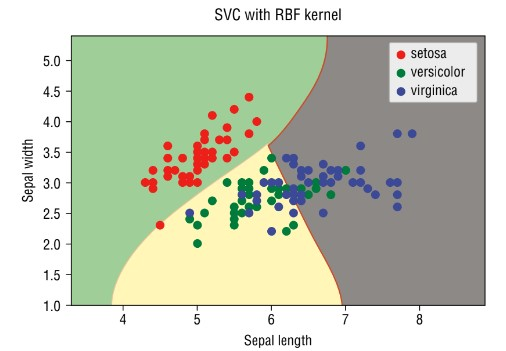

In [41]:
Image(filename='Figure-8.23.jpg')

**Şekil 8.23:** RBF çekirdeği kullanılarak eğitilen Iris veri kümesi

## GAMA

Kod parçasına dikkatlice baktığınızda, yeni bir parametre olan gama'yı keşfedeceksiniz. Gama, tek bir eğitim örneğinin etkisinin ne kadar uzaklıkta olduğunu tanımlar. Şekil 8.24'te gösterilen nokta kümesini düşünün. İki sınıf nokta vardır: x'ler ve o'lar.
Düşük bir Gama değeri, her noktanın uzak bir etkiye sahip olduğunu gösterir (Şekil 8.25'e bakın). Öte yandan, yüksek bir Gama, karar sınırına en yakın noktaların yakın bir etkiye sahip olduğu anlamına gelir. Gama'nın değeri ne kadar yüksek olursa, eğitim veri kümesine tam olarak uymaya çalışır ve sonuç olarak aşırı uyum sağlar (Şekil 8.26'ya bakın).
Şekil 8.27, C ve Gama'nın farklı değerlerini kullanarak RBF'yi kullanarak noktaların sınıflandırmasını göstermektedir.
Gama yüksekse (10), aşırı uyum meydana gelir. Bu şekilden ayrıca C'nin eğrinin düzgünlüğünü kontrol ettiğini görebilirsiniz.

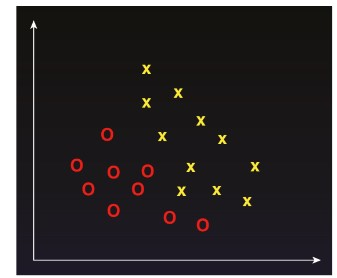

In [42]:
Image(filename='Figure-8.24.jpg')

**Şekil 8.24:** İki sınıfa ait bir nokta kümesi

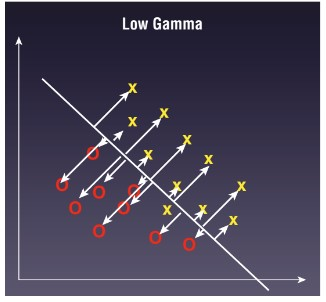

In [43]:
Image(filename='Figure-8.25.jpg')

**Şekil 8.25:** Düşük bir Gama değeri her noktanın eşit etkiye sahip olmasına izin verir

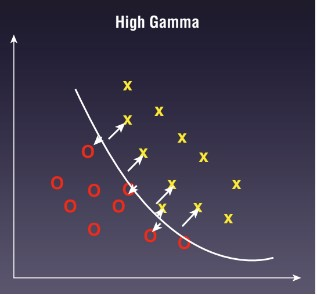

In [44]:
Image(filename='Figure-8.26.jpg')

**Şekil 8.26:** Yüksek bir Gama değeri, sınıra yakın noktalara daha fazla odaklanır

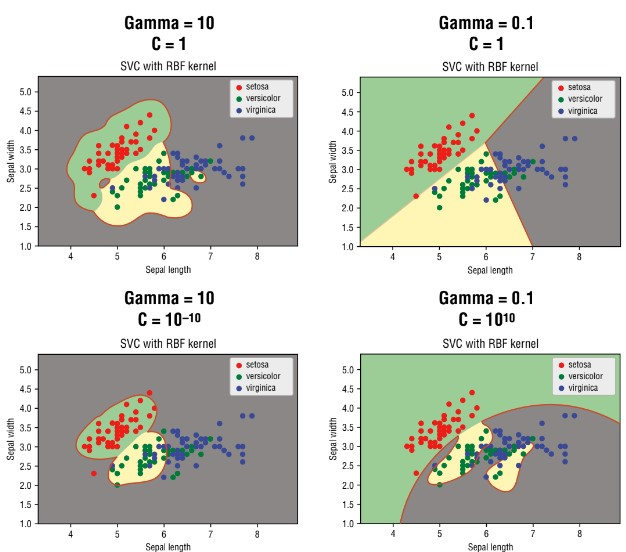

In [45]:
Image(filename='Figure-8.27.jpg')

**Şekil 8.27:** C ve Gama'nın değişen değerlerini kullanarak noktaları sınıflandırmanın etkileri

**İpucu:** Özetlemek gerekirse, C, sınırın düzgünlüğünü kontrol eder ve Gama, noktaların aşırı uyumlu olup olmadığını belirler.

## Polinom Çekirdeği

Başka bir çekirdek türüne polinom çekirdeği denir. 1. dereceden bir polinom çekirdeği, doğrusal çekirdek ile benzerdir. Daha yüksek dereceli polinom çekirdekleri daha esnek bir karar sınırı sağlar. Aşağıdaki kod parçası, derecesi 4 olan polinom çekirdeği kullanılarak eğitilen Iris veri kümesini göstermektedir:

In [46]:
C = 1 # SVM regularization parameter
clf = svm.SVC(kernel='poly', degree=4, C=C, gamma='auto').fit(X, y)
title = 'SVC with polynomial (degree 4) kernel'

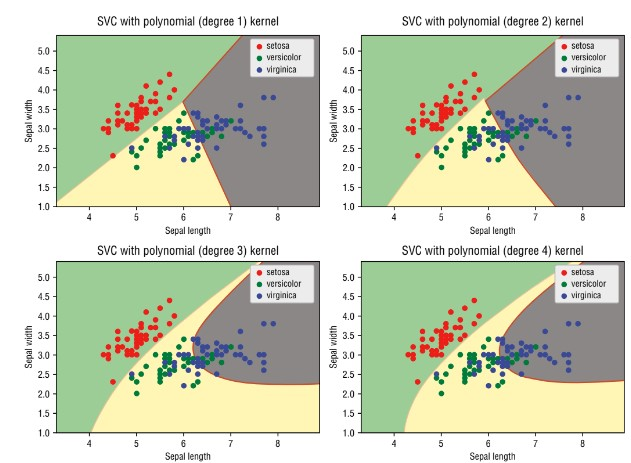

In [47]:
Image(filename='Figure-8.28.jpg')

**Şekil 8.28:** Farklı derecelerde polinom çekirdeği kullanılarak Iris veri kümesinin sınıflandırılması

## Gerçek Hayat Problemleri İçin SVM Kullanımı

Bu bölümü günlük yaşamımızda yaygın olarak karşılaşılan bir probleme SVM uygulayarak tamamlayacağız. Bir alan için evlerin boyutunu ve istenilen fiyatlarını (binlerce olarak) içeren aşağıdaki veri kümesini düşünün (house_sizes_prices_svm.csv adlı bir dosyada kaydedilmiştir):

Üçüncü sütun evin satılıp satılmadığını göstermektedir. Bu veri kümesini kullanarak, belirli bir istenen fiyata sahip bir evin satılıp satılmayacağını öğrenmek istiyorsunuz.

İlk olarak, noktaları çizelim:

C:\Users\Furkan\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


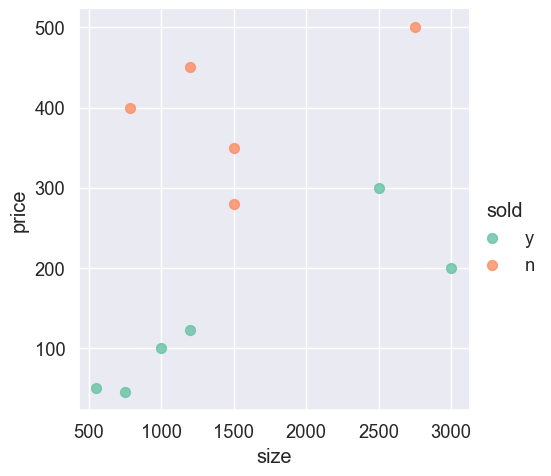

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    'size': [550, 1000, 1200, 1500, 3000, 2500, 750, 1500, 780, 1200, 2750],
    'price': [50, 100, 123, 350, 200, 300, 45, 280, 400, 450, 500],
    'sold': ['y', 'y', 'y', 'n', 'y', 'y', 'y', 'n', 'n', 'n', 'n']
})

sns.lmplot(x='size', y='price',
           data=data,
           hue='sold',
           palette='Set2',
           fit_reg=False,
           scatter_kws={"s": 50})

plt.show()

Şekil 8.29, noktaların saçılma grafiği olarak çizilmiş halini göstermektedir.

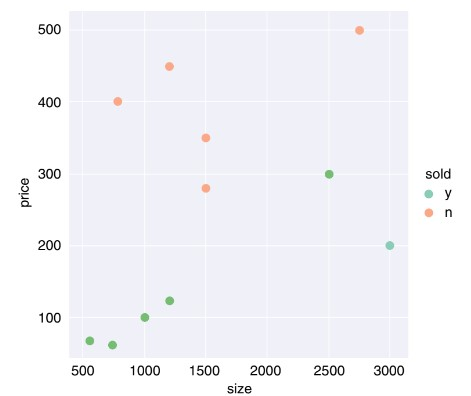

In [52]:
Image(filename='Figure-8.29.jpg')

**Şekil 8.29:** Noktaların bir saçılma grafiği üzerinde çizilmesi

Görsel olarak, bu bir problemi SVM'nin doğrusal çekirdeği ile çözebileceğinizi görebilirsiniz.

In [54]:
X = data[['size','price']].values
y = np.where(data['sold']=='y', 1, 0) #--1 for Y and 0 for N---
model = svm.SVC(kernel='linear').fit(X, y)

Eğitilmiş modelle şimdi tahminler yapabilir ve iki sınıfı belirleyebilirsiniz.

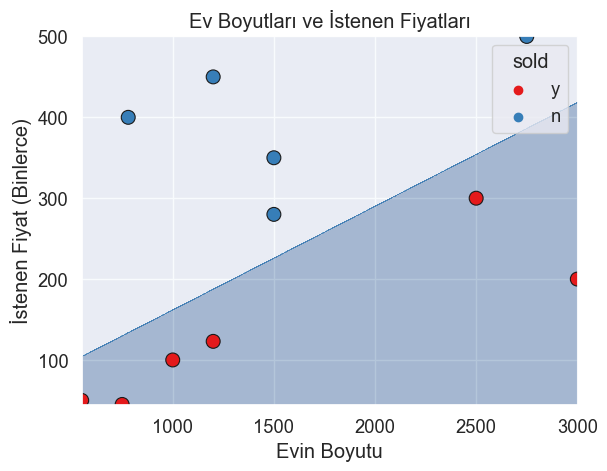

In [61]:
#---İlk özellik için min ve max---
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
#---İkinci özellik için min ve max---
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
#---Mesh üzerindeki adım boyutu---
h = (x_max / x_min) / 20
#---xx,yy'deki her bir nokta için tahminler yap---
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
#---Renkli bir grafik kullanarak sonucu çiz---
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Blues, alpha=0.3)
plt.xlabel('Evin Boyutu')
plt.ylabel('İstenen Fiyat (Binlerce)')
plt.title("Ev Boyutları ve İstenen Fiyatları")

# Veri noktalarını grafiğe ekleyelim
sns.scatterplot(x='size', y='price', hue='sold', data=data, palette='Set1', edgecolor='k', s=100)

plt.show()

Şekil 8.30, noktaları ve ait oldukları sınıfları göstermektedir.

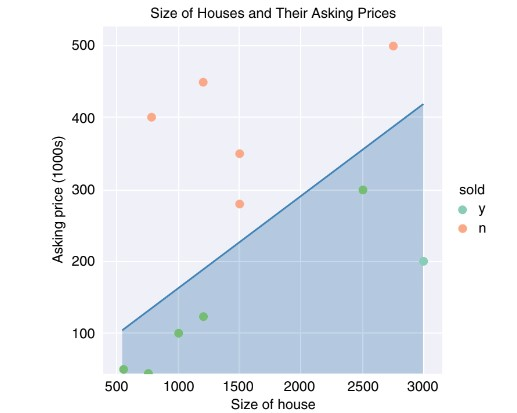

In [57]:
Image(filename='Figure-8.30.jpg')

**Şekil 8.30:** Noktaları iki sınıfa ayırma

Artık belirli bir satış fiyatına sahip belirli bir boyuttaki bir evin satılıp satılamayacağını tahmin etmeyi deneyebilirsiniz.

In [62]:
def satacak_mi(size, price):
    if model.predict([[size, price]]) == 0:
        print('Satılmayacak!')
    else:
        print('Satılacak!')

#---Tahminler yapalım---
satacak_mi(2500, 400) # Satılmayacak!
satacak_mi(2500, 200) # Satılacak!

Satılmayacak!
Satılacak!


## Özet

Bu bölümde, Destek Vektör Makinelerinin sınıflandırma problemlerine nasıl yardımcı olduğunu öğrendiniz. Hiperdüzlemi bulma formülü hakkında bilgi edindiniz, yanı sıra iki eşlik eden marjinali. Neyse ki, Scikit-learn SVM kullanarak modellerin eğitilmesi için gereken sınıfları sağlar ve döndürülen parametrelerle, hiperdüzlemi ve marjinleri görsel olarak çizebilirsiniz, böylece SVM'nin nasıl çalıştığını anlayabilirsiniz. Ayrıca, SVM algoritmalarınıza uygulayabileceğiniz çeşitli çekirdekler hakkında bilgi edindiniz, böylece veri kümesi doğrusal olarak ayrılabilir.